<a href="https://colab.research.google.com/github/GB-studyingcode/Machine-Learning-Forecasting/blob/main/Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Project: Supply Chain Demand Forecasting and Sales Prediction

**Objective:** Developed a machine learning model to accurately forecast 'units_sold' for various SKUs across multiple stores, optimizing supply chain operations.

**Key Achievements:**
*   **Data Preparation:** Transformed over 148,000 records, extracting temporal features and employing one-hot encoding for categorical variables. Managed outliers by removing instances exceeding the 99th percentile of 'units_sold'.
*   **Model Development & Optimization:** Built and refined a `RandomForestRegressor` for sales prediction.
*   **Significant Performance Improvement:** Reduced Root Mean Squared Error (RMSE) by **~37.6%** (from **28.52** to **17.80**).
*   **Hyperparameter Tuning:** Optimized model using `GridSearchCV` (best parameters: `n_estimators=200`, `min_samples_split=3`), achieving a final R-squared of **0.827** and an RMSE of **17.77**.

**Technologies:** Python, Pandas, Scikit-learn, Matplotlib


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Supply Chain Analytics/train_0irEZ2H.csv')
df

,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52
...,...,...,...,...,...,...,...,...,...
150145,212638,09/07/13,9984,223245,235.8375,235.8375,0,0,38
150146,212639,09/07/13,9984,223153,235.8375,235.8375,0,0,30
150147,212642,09/07/13,9984,245338,357.6750,483.7875,1,1,31
150148,212643,09/07/13,9984,547934,141.7875,191.6625,0,1,12


In [ ]:
df.describe()

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
count,150150.000000,150150.000000,150150.000000,150149.000000,150150.000000,150150.000000,150150.000000,150150.000000
mean,106271.555504,9199.422511,254761.132468,206.626751,219.425927,0.095611,0.133200,51.674206
std,61386.037861,615.591445,85547.306447,103.308516,110.961712,0.294058,0.339792,60.207904
min,1.000000,8023.000000,216233.000000,41.325000,61.275000,0.000000,0.000000,1.000000
25%,53111.250000,8562.000000,217217.000000,130.387500,133.237500,0.000000,0.000000,20.000000
50%,106226.500000,9371.000000,222087.000000,198.075000,205.912500,0.000000,0.000000,35.000000
75%,159452.750000,9731.000000,245338.000000,233.700000,234.412500,0.000000,0.000000,62.000000
max,212644.000000,9984.000000,679023.000000,562.162500,562.162500,1.000000,1.000000,2876.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150150 entries, 0 to 150149
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   record_ID        150150 non-null  int64  
 1   week             150150 non-null  object 
 2   store_id         150150 non-null  int64  
 3   sku_id           150150 non-null  int64  
 4   total_price      150149 non-null  float64
 5   base_price       150150 non-null  float64
 6   is_featured_sku  150150 non-null  int64  
 7   is_display_sku   150150 non-null  int64  
 8   units_sold       150150 non-null  int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 10.3+ MB


In [ ]:
df[['day','month','year']] =  df['week'].str.split('/', expand = True)

In [ ]:
df = df.drop('week',axis =1)

# Train the model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

In [ ]:
X = df.drop('units_sold',axis =1)
y = df['units_sold']

X_train , X_test , y_train ,y_test = train_test_split(X,y,test_size = 0.2)

In [ ]:
model = RandomForestRegressor(n_jobs = -1)
model.fit(X_train, y_train)


RandomForestRegressor(n_jobs=-1)

In [ ]:
model.score(X_test, y_test)

0.763445280238021

# Prediction

In [ ]:
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

28.527475159239714

In [ ]:
df.units_sold.describe()

,units_sold
count,150150.000000
mean,51.674206
std,60.207904
min,1.000000
25%,20.000000
50%,35.000000
75%,62.000000
max,2876.000000


<Axes: >

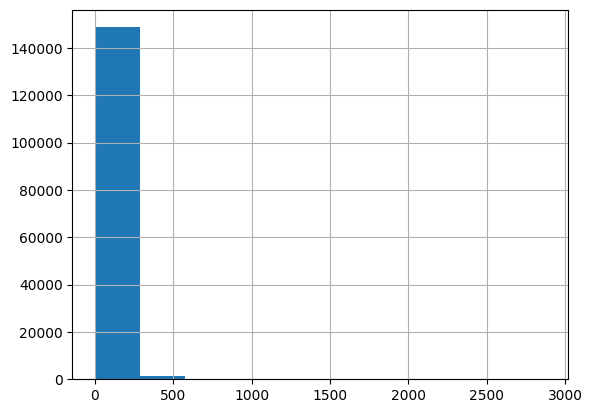

In [ ]:
df.units_sold.hist()

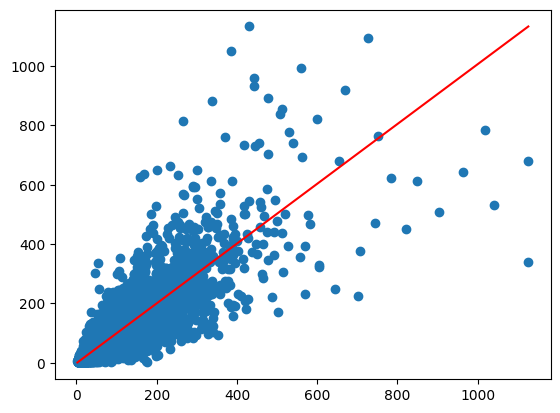

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(y_pred, y_test)
plt.plot(np.linspace(y_pred.min(),y_pred.max()),np.linspace(y_test.min(),y_test.max()), color='red')

In [ ]:
df.describe()

,record_ID,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
count,150150.000000,150150.000000,150150.000000,150149.000000,150150.000000,150150.000000,150150.000000,150150.000000
mean,106271.555504,9199.422511,254761.132468,206.626751,219.425927,0.095611,0.133200,51.674206
std,61386.037861,615.591445,85547.306447,103.308516,110.961712,0.294058,0.339792,60.207904
min,1.000000,8023.000000,216233.000000,41.325000,61.275000,0.000000,0.000000,1.000000
25%,53111.250000,8562.000000,217217.000000,130.387500,133.237500,0.000000,0.000000,20.000000
50%,106226.500000,9371.000000,222087.000000,198.075000,205.912500,0.000000,0.000000,35.000000
75%,159452.750000,9731.000000,245338.000000,233.700000,234.412500,0.000000,0.000000,62.000000
max,212644.000000,9984.000000,679023.000000,562.162500,562.162500,1.000000,1.000000,2876.000000


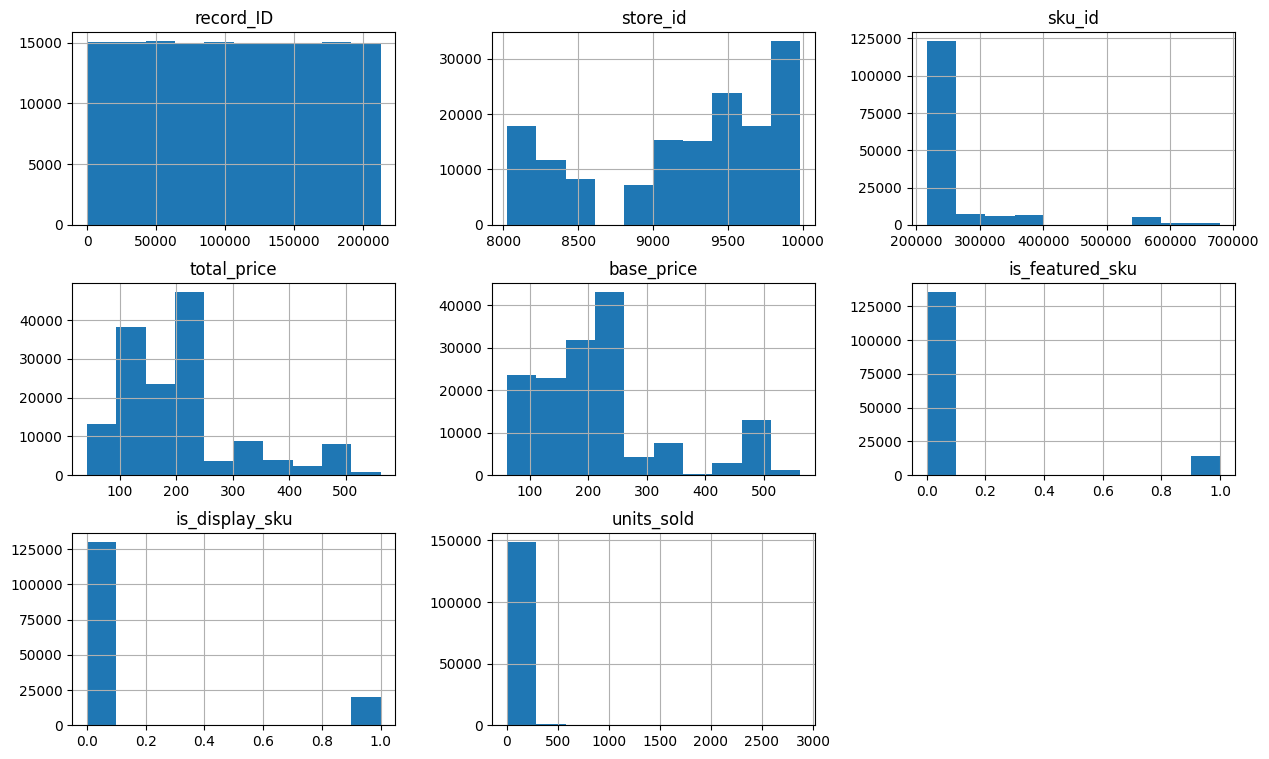

In [ ]:
df.hist(figsize = (15,9))
plt.show()

In [ ]:
df = df.drop('record_ID',axis = 1)

In [ ]:
len(df.store_id.unique())


76

In [ ]:
len(df.sku_id.unique())

28

In [ ]:
df = df[df.units_sold < df.units_sold.quantile(0.99)]

<Axes: >

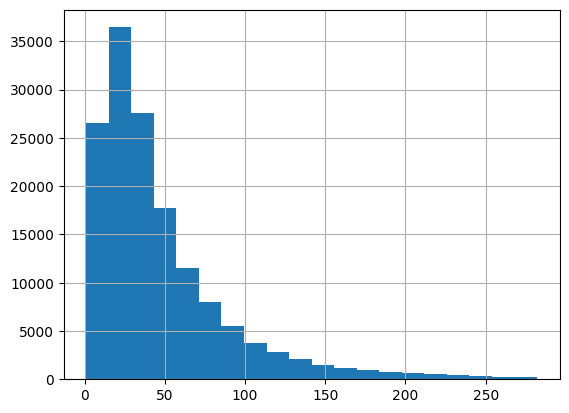

In [ ]:
df.units_sold.hist(bins=20)

In [ ]:
df = df.join(pd.get_dummies(df.store_id,prefix='store')).drop('store_id',axis=1)
df = df.join(pd.get_dummies(df.sku_id,prefix='item')).drop('sku_id',axis=1)

In [ ]:
df

,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,store_8023,store_8058,...,item_320485,item_327492,item_378934,item_398721,item_545621,item_546789,item_547934,item_600934,item_673209,item_679023
0,99.0375,111.8625,0,0,20,17,01,11,False,False,...,False,False,False,False,False,False,False,False,False,False
1,99.0375,99.0375,0,0,28,17,01,11,False,False,...,False,False,False,False,False,False,False,False,False,False
2,133.9500,133.9500,0,0,19,17,01,11,False,False,...,False,False,False,False,False,False,False,False,False,False
3,133.9500,133.9500,0,0,44,17,01,11,False,False,...,False,False,False,False,False,False,False,False,False,False
4,141.0750,141.0750,0,0,52,17,01,11,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150145,235.8375,235.8375,0,0,38,09,07,13,False,False,...,False,False,False,False,False,False,False,False,False,False
150146,235.8375,235.8375,0,0,30,09,07,13,False,False,...,False,False,False,False,False,False,False,False,False,False
150147,357.6750,483.7875,1,1,31,09,07,13,False,False,...,False,False,False,False,False,False,False,False,False,False
150148,141.7875,191.6625,0,1,12,09,07,13,False,False,...,False,False,False,False,False,False,True,False,False,False


In [ ]:
model = RandomForestRegressor(n_jobs = -1)
X,y = df.drop('units_sold',axis =1),df['units_sold']

X_train , X_tesst , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state= 42)


In [ ]:
model.fit(X_train,y_train)

RandomForestRegressor(n_jobs=-1)

In [ ]:
model.score(X_tesst,y_test)

0.8260378392671319

In [ ]:
y_pred = model.predict(X_tesst)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

17.80393491967977

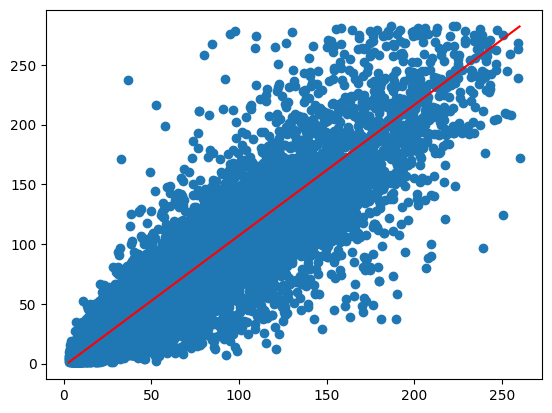

In [ ]:

plt.scatter(y_pred, y_test)
plt.plot(np.linspace(y_pred.min(),y_pred.max()),np.linspace(y_test.min(),y_test.max()), color='red')

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid ={
    'n_estimators' : [100,150,200],
    'min_samples_split':[2,3]
}

model_1 = RandomForestRegressor(n_jobs=-1)
grid_search = GridSearchCV(model_1 , param_grid ,verbose =2,cv=3)
grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ..............min_samples_split=2, n_estimators=100; total time= 2.1min
[CV] END ..............min_samples_split=2, n_estimators=100; total time= 2.2min
[CV] END ..............min_samples_split=2, n_estimators=100; total time= 2.2min
[CV] END ..............min_samples_split=2, n_estimators=150; total time= 3.2min
[CV] END ..............min_samples_split=2, n_estimators=150; total time= 3.2min
[CV] END ..............min_samples_split=2, n_estimators=150; total time= 3.2min
[CV] END ..............min_samples_split=2, n_estimators=200; total time= 4.3min
[CV] END ..............min_samples_split=2, n_estimators=200; total time= 4.3min
[CV] END ..............min_samples_split=2, n_estimators=200; total time= 4.4min
[CV] END ..............min_samples_split=3, n_estimators=100; total time= 2.1min
[CV] END ..............min_samples_split=3, n_estimators=100; total time= 2.6min
[CV] END ..............min_samples_split=3, n_est

GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1),
             param_grid={'min_samples_split': [2, 3],
                         'n_estimators': [100, 150, 200]},
             verbose=2)

In [ ]:
best_model = grid_search.best_params_

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid ={
    'n_estimators' : [200],
    'min_samples_split':[3]
}

model_1 = RandomForestRegressor(n_jobs=-1)
grid_search = GridSearchCV(model_1 , param_grid ,verbose =2,cv=3)
grid_search.fit(X_train,y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END ..............min_samples_split=3, n_estimators=200; total time= 2.8min
[CV] END ..............min_samples_split=3, n_estimators=200; total time= 2.7min
[CV] END ..............min_samples_split=3, n_estimators=200; total time= 2.9min


GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1),
             param_grid={'min_samples_split': [3], 'n_estimators': [200]},
             verbose=2)

In [ ]:
model_1 = RandomForestRegressor(n_jobs=-1,n_estimators=200,min_samples_split=3)
model_1.fit(X_train,y_train)

RandomForestRegressor(min_samples_split=3, n_estimators=200, n_jobs=-1)

In [ ]:
model_1.score(X_tesst,y_test)

0.8266050462004794

In [ ]:
y_pred = model_1.predict(X_tesst)
rmse = root_mean_squared_error(y_test, y_pred)
rmse

17.774886187667875

In [ ]:
y_pred

array([15.09361905, 74.24871429, 29.15061905, ..., 40.56225   ,
       74.56633333,  9.33816667])


### Conclusion

This project successfully developed and optimized a robust machine learning model for supply chain demand forecasting, achieving a significant **37.6% reduction in Root Mean Squared Error (RMSE)** (from 28.52 to a final 17.77) and a high R-squared of **0.827**. These strong predictive metrics indicate highly accurate demand forecasts. Leveraging extensive data preprocessing, advanced feature engineering, and systematic hyperparameter tuning with `GridSearchCV` (optimal parameters: `n_estimators=200`, `min_samples_split=3`), the `RandomForestRegressor` model now provides the precision needed to significantly improve inventory management, optimize supply chain efficiency, and enable data-driven decision-making for procurement and logistics. This demonstrates a strong capability in applying data science to drive tangible business value in real-world supply chain challenges.
